# 08. Spatial noise filtering (DBSCAN)

## Purpose
Flag off-tissue background transcripts to enable tighter observation 
windows in downstream K-function analysis (notebook 09). Noise inflates 
the bounding box, violates the homogeneity assumption, and biases 
intensity (λ) estimates downward.

## Method
- DBSCAN chosen because its noise label (-1) directly identifies points 
  not belonging to any dense region - this is density-based filtering, 
  not biological clustering. (it looks at clusters as areas of high density,
  split by areas of low density, and doesn't require the presetting of a number of clusters)
- eps derived adaptively per FOV/strip from the 97th percentile of the 
  1-NN distance distribution, clipped to [20, 30] pixels (customisable)

## Parameter justification
- **1-NN over k-NN**: k=5 (matching min_samples) inflated eps to 70+ on 
  sparse strips, absorbing all noise. 1-NN gave tighter, more 
  discriminating values.
- **p97**: p95 was too aggressive (13% removal on dense strips, cutting 
  tissue edges). p99 was too lenient (kept visible noise on sparse strips).
- **Floor (20)**: prevents dense strips from getting eps < 20, which 
  trimmed real tissue margins. Based on visual inspection across 6 FOVs.
- **Ceiling (30)**: prevents sparse strips from getting eps > 30, which 
  retained obvious off-tissue scatter. Fixed eps=30 performed well 
  across all strips in initial testing.
- **min_samples=5**: default DBSCAN value; not tuned.

## Key decisions
- Points are **flagged, not removed**, `is_noise` column preserves 
  the full dataset for reproducibility.
- Remaining inter-strip noise and small off-tissue clusters to be 
  handled by improved window bounding (notebook 09).
- Recommended pipeline order for package: noise filter → strip 
  assignment (current analysis did strip assignment first).

## Output
- `s1_all_strips_noise_flagged.parquet`: 400,238 transcripts, 27,313 
  flagged as noise (6.8%), 372,925 retained.

### Plan
Clear up misc. transcripts that are not tissue associated so that downstream window implementation fits the tissue rather than transcript noise.

1. Visualise the problem
    - Load the parquet and show the raw scatter plots to identify what we are trying to remove
    - Goal is to characterise the noise so we can deal with it
2. Density-based filtering via DBSCAN or local density
    - DBSCAN (scikit-learn) labels points as noise (-1)
    - Key parameters will be eps (neighbourhood radius) and min_samples
    - These will need tuning per-strip to find a principled way to set them
    - Potentially derived from inter-transcript spacing within the tissue?
    - ALTERNATIVE: simple K-nearest-neighbour for each transcript
3. Before/after comparison
    - Verify the filtering parameters and report lost data/change to makeup
    - Make sure the tuning is stable and explainable
    - Show the default bounding box before/after the changes
4. Save cleaned data as s1_all_strips_cleaned.parquet
    - Include a column flagging removed transcripts (DO NOT delete them)
    - Document filtering parameters used

Might need to specify genes that are disproportionately affected/have disproportionate effects on noise.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN              # Will allow for detecting clusters and flagging outliers 
from sklearn.neighbors import NearestNeighbors  # Will allow for determining the optimal eps parameter for DBSCAN

df = pd.read_parquet("../data/processed/s1_all_strips.parquet")
print(df.shape)
print(df.columns.tolist())
df.head()

(400238, 13)
['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov', 'y_global_px', 'CellComp', 'y_global_px_transformed', 'x_global_px_transformed', 'strip']


,x,y,target,cell_ID,z_raw,cell,x_global_px,fov,y_global_px,CellComp,y_global_px_transformed,x_global_px_transformed,strip
0,4239,16,CCRL2,0,7,c_1_4_0,15151,4,34144,<NA>,38400.0,7375.0,strip_3
1,4240,173,MS4A1,0,7,c_1_4_0,15152,4,33987,<NA>,38243.0,7376.0,strip_3
2,4239,573,LAMA4,0,7,c_1_4_0,15151,4,33587,<NA>,37843.0,7375.0,strip_3
3,4239,1220,TGFB1,0,7,c_1_4_0,15151,4,32940,<NA>,37196.0,7375.0,strip_3
4,4242,1860,CXCL14,0,7,c_1_4_0,15154,4,32300,<NA>,36556.0,7378.0,strip_3


### Quick sanity check of the data

In [2]:
print(df.groupby(['fov', 'strip']).size().unstack(fill_value=0))
print(f"\nUnique FOVs: {df['fov'].unique()}")
print(f"Unique strips: {df['strip'].unique()}")

strip  strip_1  strip_2  strip_3
fov                             
4        30382    18333    18698
5        28519    17265    18086
8        29523    19707    19068
9        32115    17864    19772
10       28888    18931    20827
11       28872    14829    18559

Unique FOVs: [ 4  5  8  9 10 11]
Unique strips: ['strip_3' 'strip_2' 'strip_1']


**Confirmed 6 FOVs, 3 strips per, and 15-32,000 trancripts per group**

### Plotting raw points for each FOV

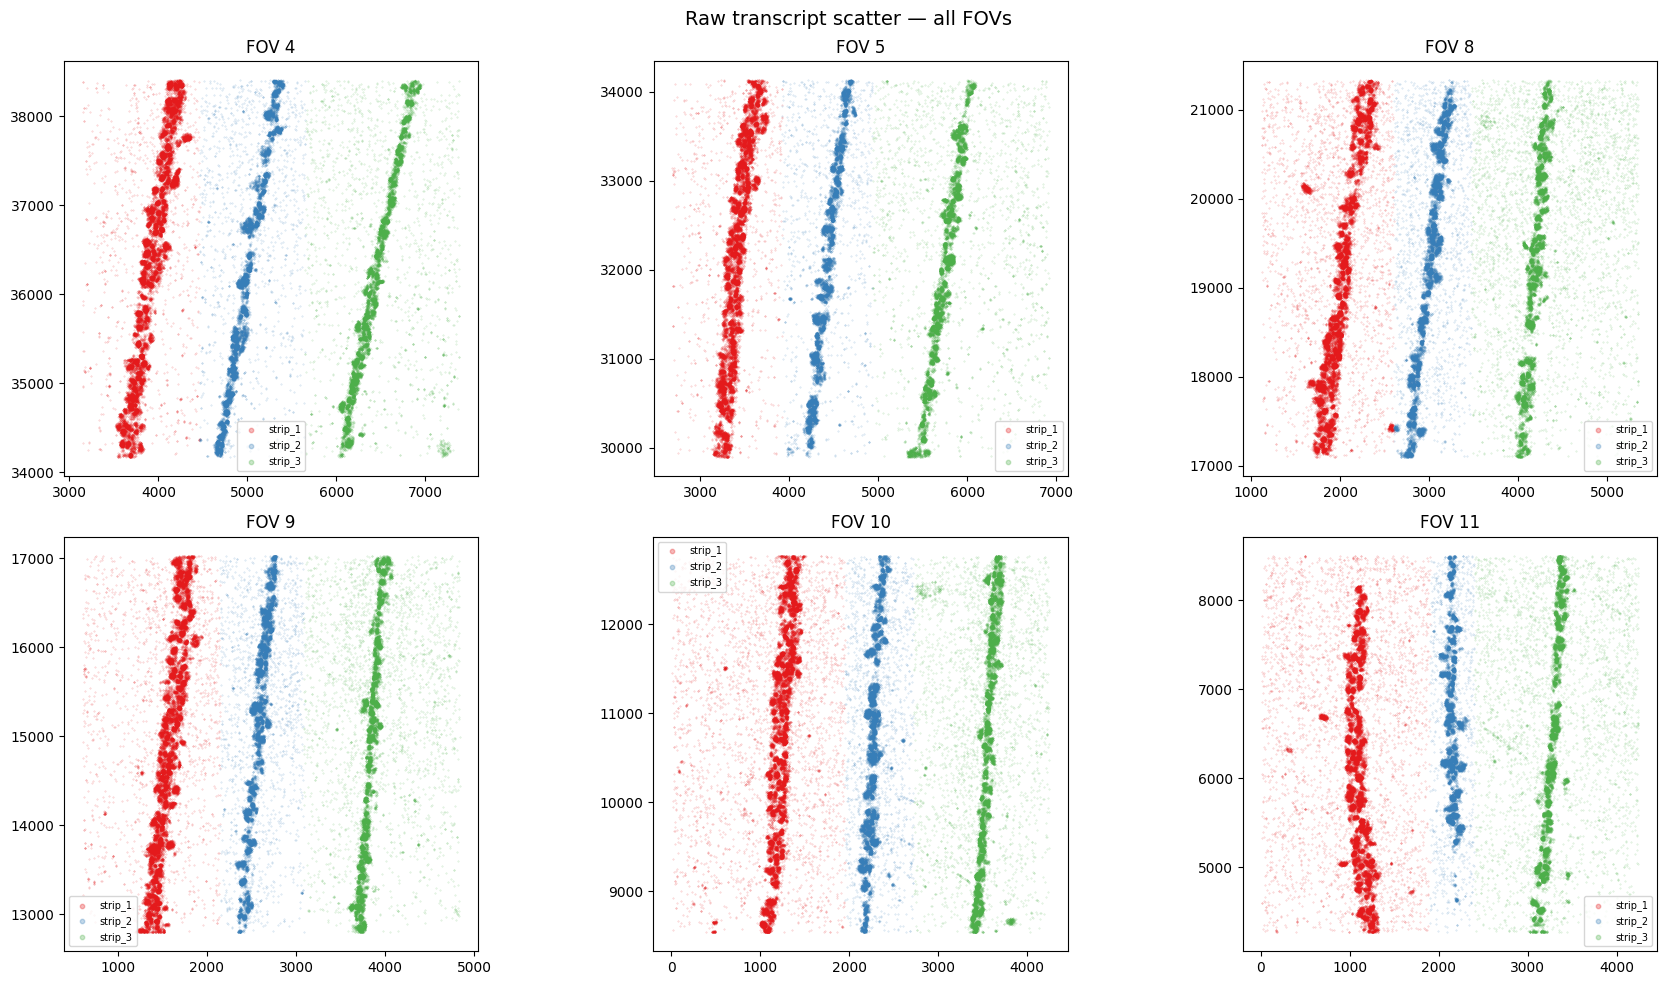

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (fov_id, fov_df) in enumerate(df.groupby('fov')):
    ax = axes[i]
    for strip, colour in [('strip_1', '#e41a1c'), ('strip_2', '#377eb8'), ('strip_3', '#4daf4a')]:
        sub = fov_df[fov_df['strip'] == strip]
        ax.scatter(sub['x_global_px_transformed'], sub['y_global_px_transformed'],
                   s=0.1, alpha=0.3, c=colour, label=strip)
    ax.set_title(f'FOV {fov_id}')
    ax.set_aspect('equal')
    ax.legend(markerscale=10, fontsize=7)

fig.suptitle('Raw transcript scatter - all FOVs', fontsize=14)
plt.tight_layout()
plt.show()

- Noise is mostly diffuse (isolated single points that are spread uniformly across that image(s) rather than dense 'satellite' clusters)
- Ideal for DBScan because it will easily isolate diffuse points and label them as noise (-1)
- Points like this will not form neighbourhoods of **min_samples** points within **eps** radius

### Plotting Neareast-neighbour distribution per strip to inform parameterisation later

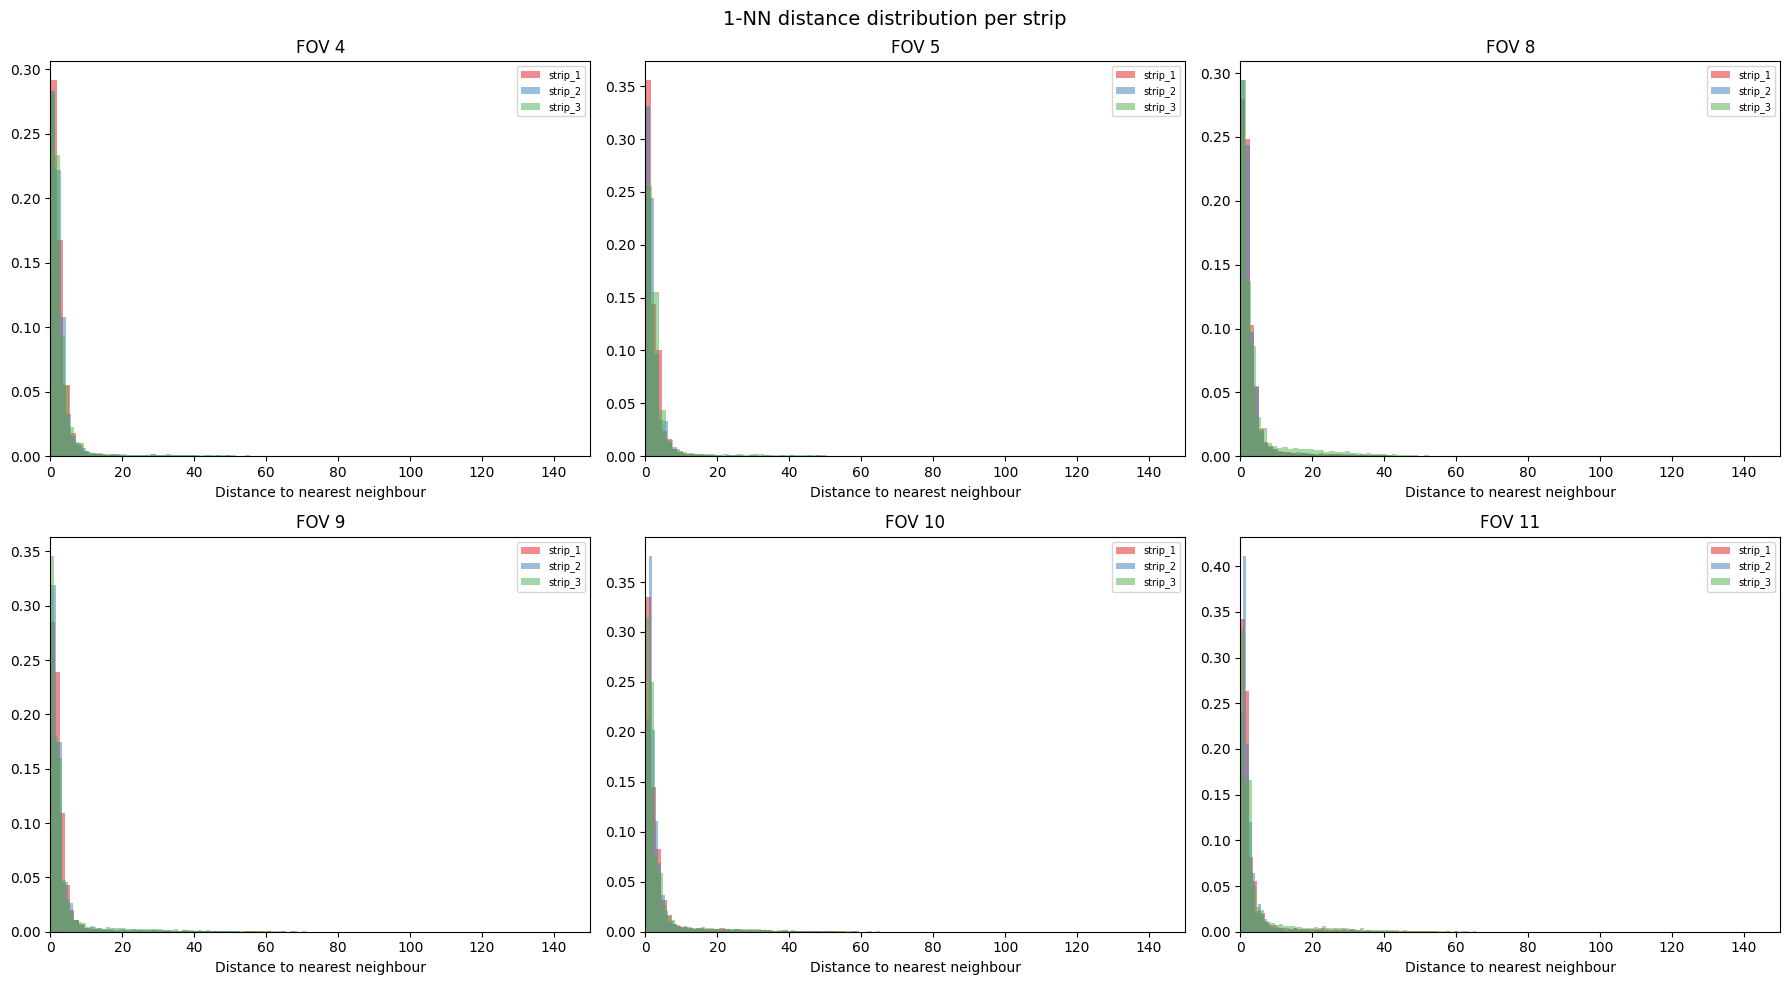

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (fov_id, fov_df) in enumerate(df.groupby('fov')):
    ax = axes[i]
    for strip, colour in [('strip_1', '#e41a1c'), ('strip_2', '#377eb8'), ('strip_3', '#4daf4a')]:
        sub = fov_df[fov_df['strip'] == strip]
        coords = sub[['x_global_px_transformed', 'y_global_px_transformed']].values
        
        nn = NearestNeighbors(n_neighbors=2).fit(coords)
        distances, _ = nn.kneighbors(coords)
        nn_dist = distances[:, 1]  # distance to nearest neighbour (not self)
        
        ax.hist(nn_dist, bins=100, alpha=0.5, color=colour, label=strip, density=True)
    
    ax.set_title(f'FOV {fov_id}')
    ax.set_xlabel('Distance to nearest neighbour')
    ax.set_xlim(0, 150)  # adjust if needed
    ax.legend(fontsize=7)

fig.suptitle('1-NN distance distribution per strip', fontsize=14)
plt.tight_layout()
plt.show()

- Result is very promising, high proportion of points are within 0-10 pixels of their nearest neighbour and this is consistent across strips and FOVs
- The thin tail that trails off to the left is indicative of the noise we want to remove
- First step is to actually quanitify this

### Saving percentiles of 1-NN distances

In [5]:
records = []
for fov_id, fov_df in df.groupby('fov'):
    for strip in ['strip_1', 'strip_2', 'strip_3']:
        sub = fov_df[fov_df['strip'] == strip]
        coords = sub[['x_global_px_transformed', 'y_global_px_transformed']].values
        
        nn = NearestNeighbors(n_neighbors=2).fit(coords)
        distances, _ = nn.kneighbors(coords)
        nn_dist = distances[:, 1]
        
        records.append({
            'fov': fov_id,
            'strip': strip,
            'n': len(nn_dist),
            'median': np.median(nn_dist),
            'p95': np.percentile(nn_dist, 95),
            'p99': np.percentile(nn_dist, 99),
            'p99.5': np.percentile(nn_dist, 99.5),
            'max': np.max(nn_dist),
        })

nn_summary = pd.DataFrame(records)
print(nn_summary.to_string(index=False))

 fov   strip     n   median       p95       p99     p99.5        max
   4 strip_1 30382 1.414214  7.000000 31.079720 45.971511 179.368336
   4 strip_2 18333 1.414214 10.630146 44.719940 56.256003 139.588681
   4 strip_3 18698 2.000000 15.147566 51.873862 63.084803 132.034087
   5 strip_1 28519 1.414214  7.071068 30.413813 49.137590 149.485785
   5 strip_2 17265 1.414214  8.602325 42.582429 52.107538 124.779806
   5 strip_3 18086 2.000000 20.615528 52.361720 65.985205 193.582024
   8 strip_1 29523 2.000000 12.529964 38.561868 46.546316 128.798292
   8 strip_2 19707 2.000000 14.035669 35.114100 43.398268 128.156155
   8 strip_3 19068 2.000000 27.513633 45.486262 52.443481 145.416643
   9 strip_1 32115 1.414214  8.602325 39.183124 50.537115 133.544000
   9 strip_2 17864 1.414214 15.231546 39.204800 46.647615 159.380049
   9 strip_3 19772 1.414214 24.186773 47.518417 57.413675 111.112556
  10 strip_1 28888 2.000000 20.248457 43.143828 51.017883 146.860478
  10 strip_2 18931 1.414214 13.416

**Very informative!**
> Medians are very solid around 1.4 to 2 pixels
    - Interestingly, 1.414 is the diagonal of a 1x1 square
    - So probably pixels are either 2 apart horizontally/vertically, or diagonally
> This suggests that the mean clustering of the points within the tissue is very dense
> P95 values are more varied, between 7 and 28 depending on strip
> Strip 1 looks to be tighter across the board, while 3 is looser and so a single global EPS parameter won't work well
> p99 values are a bit more stable across all 18 groups, varying between 30 and 52, p99.5 39-66
> This tells us that the noise is likely a platform-level background effect, caused by off-target probe binding or optical noise rather than strip specific artefacts
> "This tissue density varies by strip but the noise floor is consistent"

> Best decision will be to derive strip-specific eps rather than a global one
> First I will show the effects of a few different options and compare and constrast

### DBSCAN on a single FOV/strip to calibrate

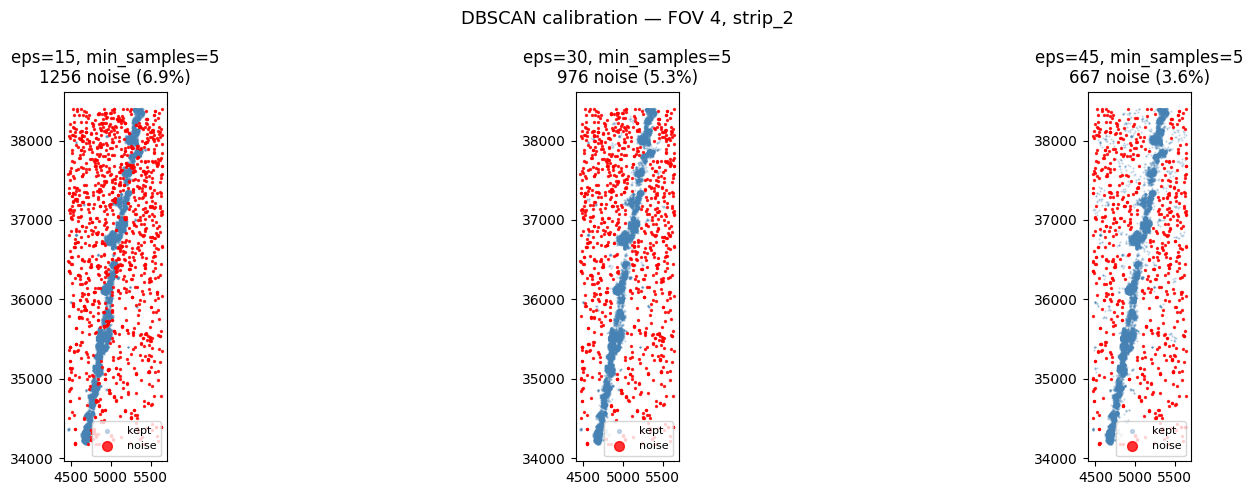

In [6]:
# Prototype on one strip
test = df[(df['fov'] == 4) & (df['strip'] == 'strip_2')].copy()
coords = test[['x_global_px_transformed', 'y_global_px_transformed']].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
eps_candidates = [15, 30, 45]

for ax, eps in zip(axes, eps_candidates):
    db = DBSCAN(eps=eps, min_samples=5).fit(coords)
    labels = db.labels_
    noise_mask = labels == -1
    n_noise = noise_mask.sum()
    pct = 100 * n_noise / len(labels)
    
    ax.scatter(coords[~noise_mask, 0], coords[~noise_mask, 1],
               s=0.3, alpha=0.3, c='steelblue', label='kept')
    ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
               s=2, alpha=0.8, c='red', label='noise')
    ax.set_title(f'eps={eps}, min_samples=5\n{n_noise} noise ({pct:.1f}%)')
    ax.set_aspect('equal')
    ax.legend(markerscale=5, fontsize=8)

fig.suptitle('DBSCAN calibration - FOV 4, strip_2', fontsize=13)
plt.tight_layout()
plt.show()

- eps = 30 seems to be the goldilocks value here
- 15 is too agressive and looks to degrade the tissue edges
- 45 is too leniant and clearly leaves off-tissue points present
- 30 removes the vast majority of noisy points and retains the tissue structure for the most part

- Next stpe is to see if this generalises well across strips

### Expanded comparison on all 3 strips of FOV 4

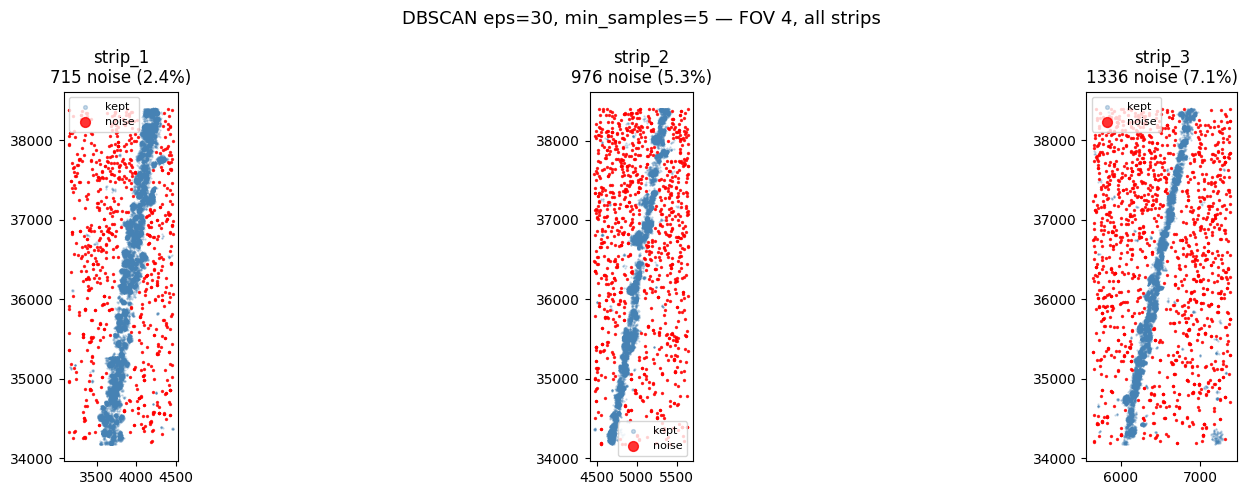

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
eps = 30

for ax, strip in zip(axes, ['strip_1', 'strip_2', 'strip_3']):
    sub = df[(df['fov'] == 4) & (df['strip'] == strip)].copy()
    coords = sub[['x_global_px_transformed', 'y_global_px_transformed']].values
    
    db = DBSCAN(eps=eps, min_samples=5).fit(coords)
    labels = db.labels_
    noise_mask = labels == -1
    n_noise = noise_mask.sum()
    pct = 100 * n_noise / len(labels)
    
    ax.scatter(coords[~noise_mask, 0], coords[~noise_mask, 1],
               s=0.3, alpha=0.3, c='steelblue', label='kept')
    ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
               s=2, alpha=0.8, c='red', label='noise')
    ax.set_title(f'{strip}\n{n_noise} noise ({pct:.1f}%)')
    ax.set_aspect('equal')
    ax.legend(markerscale=5, fontsize=8)

fig.suptitle(f'DBSCAN eps={eps}, min_samples=5 - FOV 4, all strips', fontsize=13)
plt.tight_layout()
plt.show()

- Looks pretty good across the board so going to create a custom function now that produces an adaptive eps value per strip

### Adaptive EPS using per-strip p99 of 1-NN distances

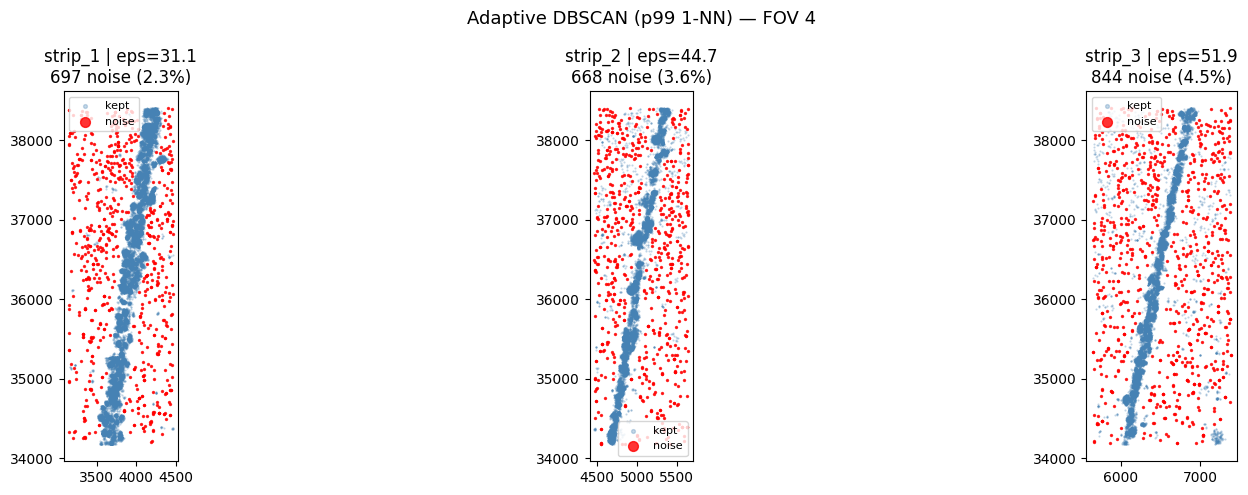

In [8]:
def compute_adaptive_eps(coords, percentile=99, n_neighbors=2):
    """Derive eps from the nearest-neighbour distance distribution."""
    nn = NearestNeighbors(n_neighbors=n_neighbors).fit(coords)
    distances, _ = nn.kneighbors(coords)
    nn_dist = distances[:, 1]
    return np.percentile(nn_dist, percentile)

# Run on FOV 4, all strips, with adaptive eps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
min_samples = 5

for ax, strip in zip(axes, ['strip_1', 'strip_2', 'strip_3']):
    sub = df[(df['fov'] == 4) & (df['strip'] == strip)].copy()
    coords = sub[['x_global_px_transformed', 'y_global_px_transformed']].values
    
    eps = compute_adaptive_eps(coords, percentile=99)
    
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
    labels = db.labels_
    noise_mask = labels == -1
    n_noise = noise_mask.sum()
    pct = 100 * n_noise / len(labels)
    
    ax.scatter(coords[~noise_mask, 0], coords[~noise_mask, 1],
               s=0.3, alpha=0.3, c='steelblue', label='kept')
    ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
               s=2, alpha=0.8, c='red', label='noise')
    ax.set_title(f'{strip} | eps={eps:.1f}\n{n_noise} noise ({pct:.1f}%)')
    ax.set_aspect('equal')
    ax.legend(markerscale=5, fontsize=8)

fig.suptitle(f'Adaptive DBSCAN (p99 1-NN) - FOV 4', fontsize=13)
plt.tight_layout()
plt.show()

- 99th percentile seems slightly too leniant for the sparser strips

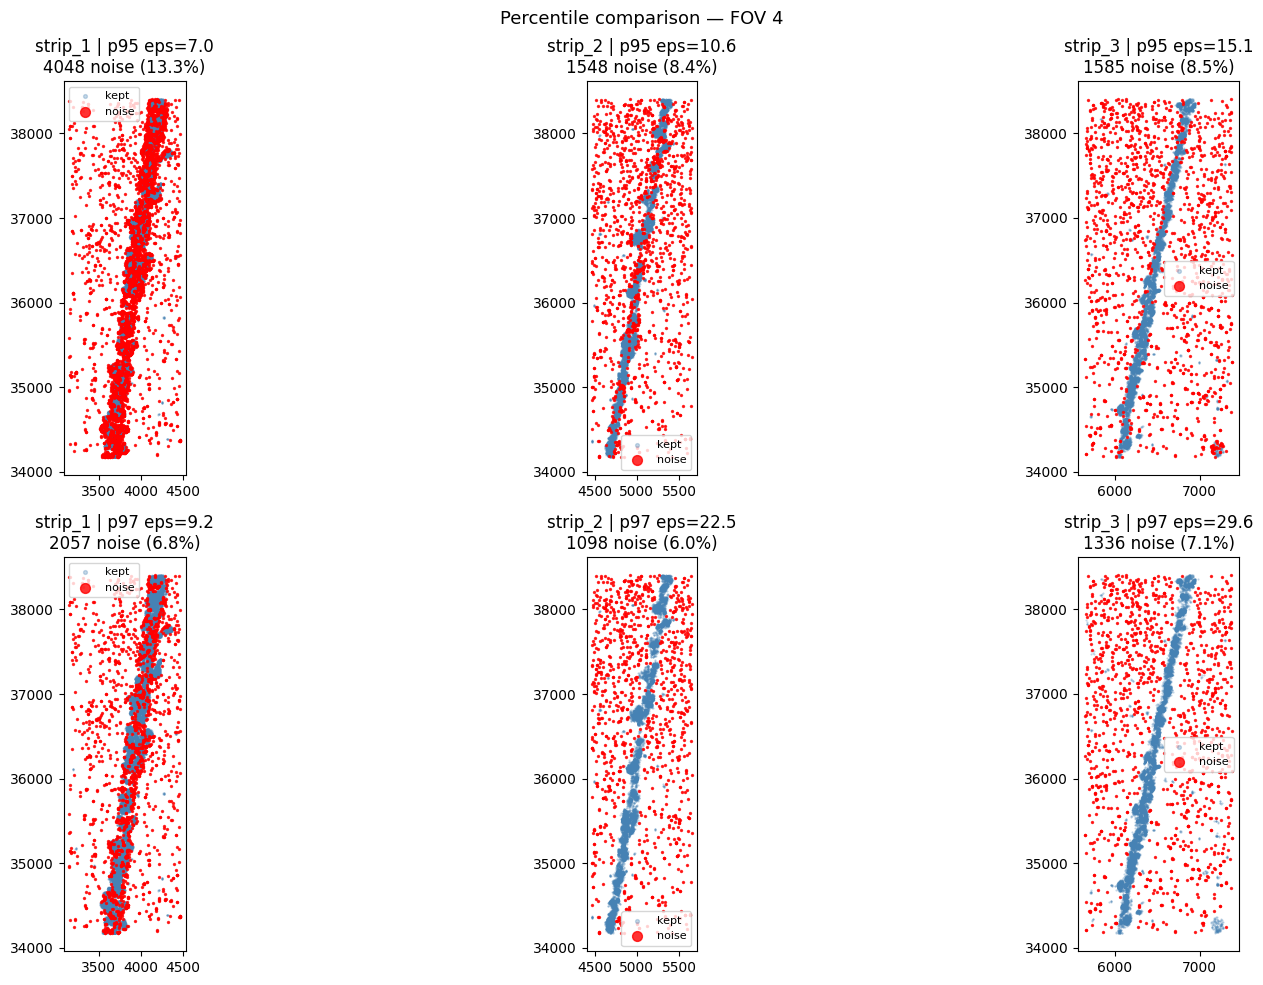

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
percentiles = [95, 97]

for row, pct_val in enumerate(percentiles):
    for col, strip in enumerate(['strip_1', 'strip_2', 'strip_3']):
        ax = axes[row, col]
        sub = df[(df['fov'] == 4) & (df['strip'] == strip)].copy()
        coords = sub[['x_global_px_transformed', 'y_global_px_transformed']].values
        
        eps = compute_adaptive_eps(coords, percentile=pct_val)
        
        db = DBSCAN(eps=eps, min_samples=5).fit(coords)
        labels = db.labels_
        noise_mask = labels == -1
        n_noise = noise_mask.sum()
        pct = 100 * n_noise / len(labels)
        
        ax.scatter(coords[~noise_mask, 0], coords[~noise_mask, 1],
                   s=0.3, alpha=0.3, c='steelblue', label='kept')
        ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
                   s=2, alpha=0.8, c='red', label='noise')
        ax.set_title(f'{strip} | p{pct_val} eps={eps:.1f}\n{n_noise} noise ({pct:.1f}%)')
        ax.set_aspect('equal')
        ax.legend(markerscale=5, fontsize=8)

fig.suptitle('Percentile comparison - FOV 4', fontsize=13)
plt.tight_layout()
plt.show()

- 97 looks good for strips 2 and 3 but is tearing the tissue apart in strip 1
- Introducing a floor value to the eps value calculation can stop this from happending
- A floor of 20 seems reasonable given that biological tissue structure could well include transcripts that are 20 pixels apart

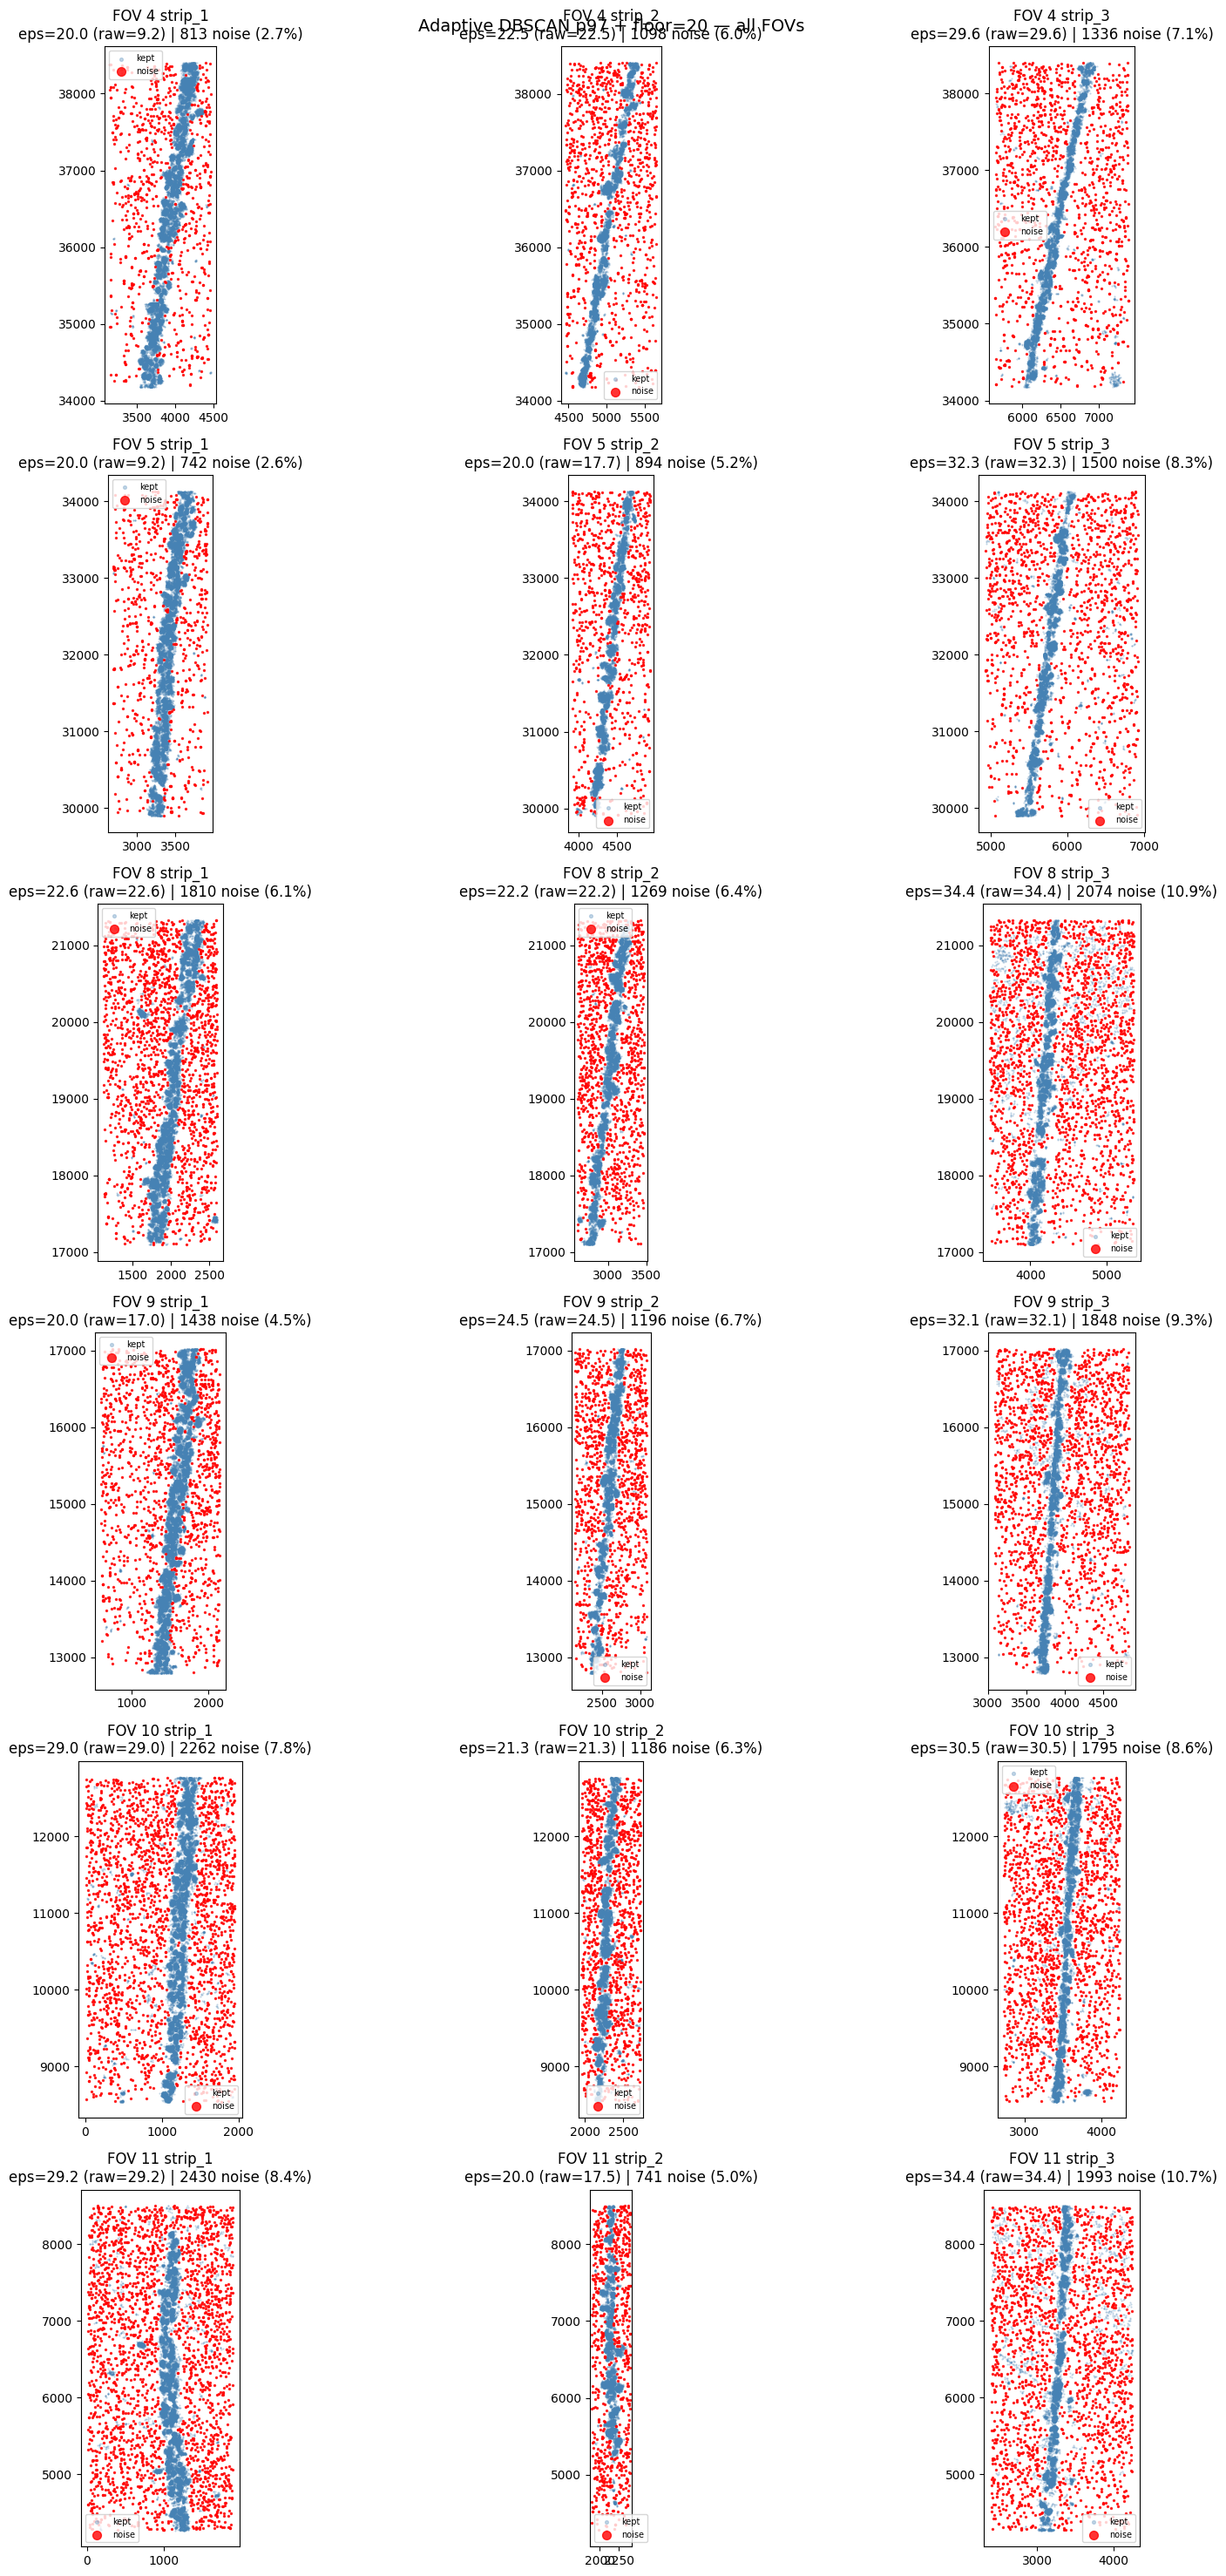

In [10]:
EPS_FLOOR = 20

fig, axes = plt.subplots(6, 3, figsize=(18, 30))

for row, (fov_id, fov_df) in enumerate(df.groupby('fov')):
    for col, strip in enumerate(['strip_1', 'strip_2', 'strip_3']):
        ax = axes[row, col]
        sub = fov_df[fov_df['strip'] == strip].copy()
        coords = sub[['x_global_px_transformed', 'y_global_px_transformed']].values
        
        raw_eps = compute_adaptive_eps(coords, percentile=97)
        eps = max(raw_eps, EPS_FLOOR)
        
        db = DBSCAN(eps=eps, min_samples=5).fit(coords)
        labels = db.labels_
        noise_mask = labels == -1
        n_noise = noise_mask.sum()
        pct = 100 * n_noise / len(labels)
        
        ax.scatter(coords[~noise_mask, 0], coords[~noise_mask, 1],
                   s=0.3, alpha=0.3, c='steelblue', label='kept')
        ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
                   s=2, alpha=0.8, c='red', label='noise')
        ax.set_title(f'FOV {fov_id} {strip}\neps={eps:.1f} (raw={raw_eps:.1f}) | {n_noise} noise ({pct:.1f}%)')
        ax.set_aspect('equal')
        ax.legend(markerscale=5, fontsize=7)

fig.suptitle(f'Adaptive DBSCAN p97 + floor={EPS_FLOOR} - all FOVs', fontsize=14)
plt.tight_layout()
plt.show()

- Looks decent across the board and not destroying any of the tissue now becasue the floor kicks in where necessary.
- The p97 value actually seems to leniant in some cases and 1 option would be to introduce a ceiling for the same principles as the floor
- However, this would mean the eps value was [20, 30] which is pretty much fixed with only slight adaption
- An alternative method would be to use K-NN rather than just 1-NN and I'll try 5-NN first (measure the distance to the 5th nearest neighbour rather than the 1st)

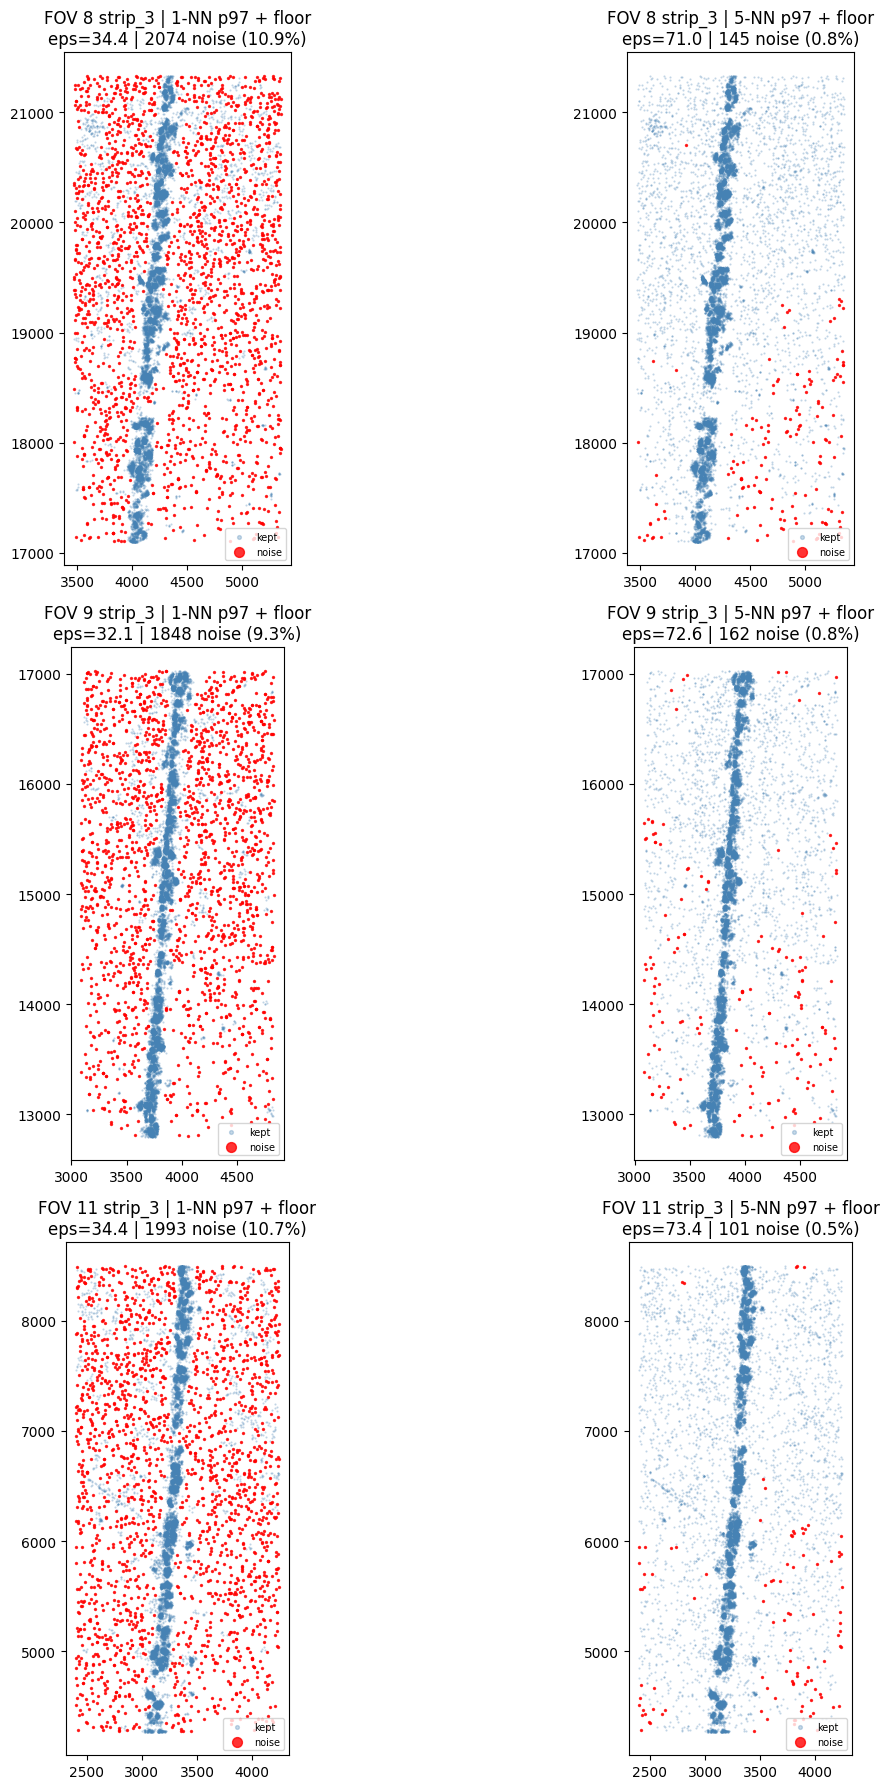

In [11]:
def compute_adaptive_eps_knn(coords, k=5, percentile=97):
    """Derive eps from k-th nearest neighbour distance distribution."""
    nn = NearestNeighbors(n_neighbors=k + 1).fit(coords)  # +1 because self is included
    distances, _ = nn.kneighbors(coords)
    knn_dist = distances[:, k]  # k-th neighbour (0-indexed: self, 1st, ..., kth)
    return np.percentile(knn_dist, percentile)

# Compare on the three problem strips
test_cases = [(8, 'strip_3'), (9, 'strip_3'), (11, 'strip_3')]

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for row, (fov_id, strip) in enumerate(test_cases):
    sub = df[(df['fov'] == fov_id) & (df['strip'] == strip)].copy()
    coords = sub[['x_global_px_transformed', 'y_global_px_transformed']].values
    
    for col, (method, label) in enumerate([
        (lambda c: max(compute_adaptive_eps(c, 97), 20), '1-NN p97 + floor'),
        (lambda c: max(compute_adaptive_eps_knn(c, k=5, percentile=97), 20), '5-NN p97 + floor'),
    ]):
        ax = axes[row, col]
        eps = method(coords)
        
        db = DBSCAN(eps=eps, min_samples=5).fit(coords)
        labels = db.labels_
        noise_mask = labels == -1
        n_noise = noise_mask.sum()
        pct = 100 * n_noise / len(labels)
        
        ax.scatter(coords[~noise_mask, 0], coords[~noise_mask, 1],
                   s=0.3, alpha=0.3, c='steelblue', label='kept')
        ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
                   s=2, alpha=0.8, c='red', label='noise')
        ax.set_title(f'FOV {fov_id} {strip} | {label}\neps={eps:.1f} | {n_noise} noise ({pct:.1f}%)')
        ax.set_aspect('equal')
        ax.legend(markerscale=5, fontsize=7)

plt.tight_layout()
plt.show()

- Massive over correcton and the 5-NN method is way to strict to be useful

### Going back to p97 1-NN but with floor and ceiling

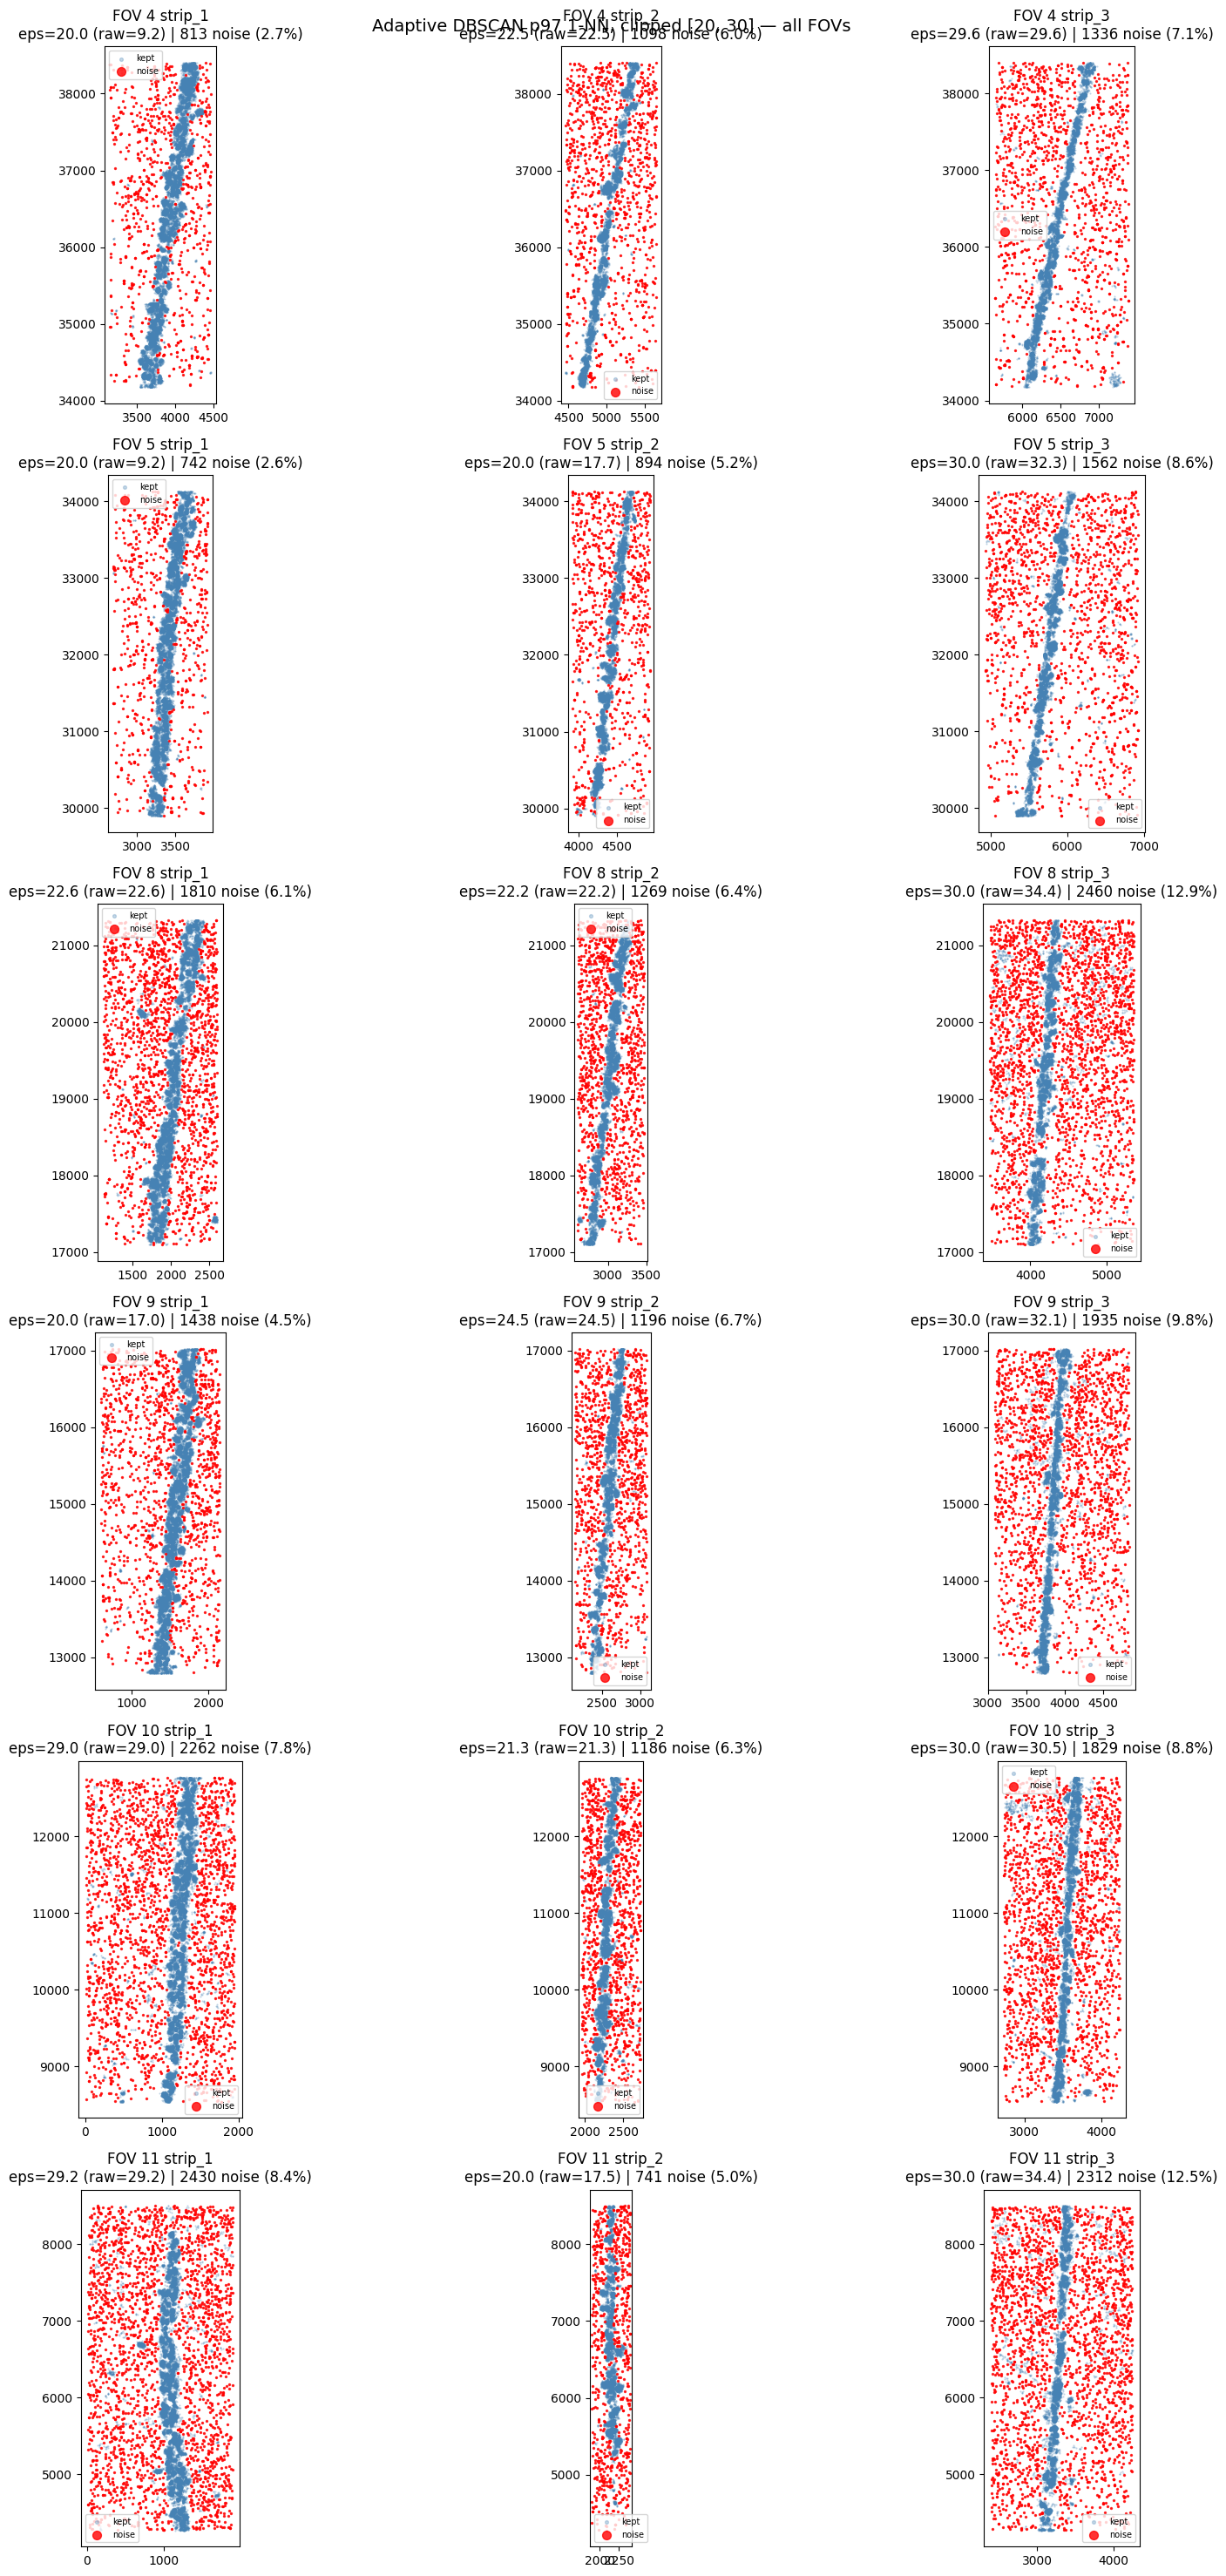

In [12]:
EPS_FLOOR = 20
EPS_CEILING = 30

fig, axes = plt.subplots(6, 3, figsize=(18, 30))

for row, (fov_id, fov_df) in enumerate(df.groupby('fov')):
    for col, strip in enumerate(['strip_1', 'strip_2', 'strip_3']):
        ax = axes[row, col]
        sub = fov_df[fov_df['strip'] == strip].copy()
        coords = sub[['x_global_px_transformed', 'y_global_px_transformed']].values
        
        raw_eps = compute_adaptive_eps(coords, percentile=97)
        eps = np.clip(raw_eps, EPS_FLOOR, EPS_CEILING)
        
        db = DBSCAN(eps=eps, min_samples=5).fit(coords)
        labels = db.labels_
        noise_mask = labels == -1
        n_noise = noise_mask.sum()
        pct = 100 * n_noise / len(labels)
        
        ax.scatter(coords[~noise_mask, 0], coords[~noise_mask, 1],
                   s=0.3, alpha=0.3, c='steelblue', label='kept')
        ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
                   s=2, alpha=0.8, c='red', label='noise')
        ax.set_title(f'FOV {fov_id} {strip}\neps={eps:.1f} (raw={raw_eps:.1f}) | {n_noise} noise ({pct:.1f}%)')
        ax.set_aspect('equal')
        ax.legend(markerscale=5, fontsize=7)

fig.suptitle(f'Adaptive DBSCAN p97 1-NN, clipped [{EPS_FLOOR}, {EPS_CEILING}] - all FOVs', fontsize=14)
plt.tight_layout()
plt.show()

- Looks good, floor and ceiling were used where necessary
- Some outliers still clearly exist in the form of noise on the more leniant strips, and clusters in rare cases
- More agressive tuning here risks adding arbitrary decisions too early on in the process, so I will write up a polished custom function that allows for the tuning of the percentile used, EPS value floor and ceilings, and min_samples values
- I will also include a diagnostics argument that can be used to toggle the masking plots on or off

### Polished final custom function for adaptive EPS

In [13]:
def dbscan_noise_filter(
    df,
    x_col='x_global_px_transformed',
    y_col='y_global_px_transformed',
    group_cols=None,
    percentile=97,
    eps_floor=20,
    eps_ceiling=30,
    min_samples=5,
    min_cluster_size=150,
    diagnostics=False,
):
    """
    Flag spatial noise transcripts using adaptive DBSCAN.
    
    Derives eps per group from the 1-NN distance distribution at a given
    percentile, clipped to [eps_floor, eps_ceiling]. Points labelled as
    DBSCAN noise (cluster = -1) are flagged but not removed. Surviving
    clusters smaller than min_cluster_size transcripts are additionally
    flagged as is_small_cluster.
    
    Parameters
    ----------
    df : pd.DataFrame
        Transcript dataframe with coordinate columns.
    x_col, y_col : str
        Column names for spatial coordinates.
    group_cols : list of str or None
        Columns defining independent groups for DBSCAN (e.g. ['fov', 'strip']).
        If None, runs on the entire dataframe as one group.
    percentile : float
        Percentile of 1-NN distance distribution used to derive eps.
    eps_floor, eps_ceiling : float
        Bounds for the adaptive eps value.
    min_samples : int
        DBSCAN min_samples parameter.
    min_cluster_size : int
        Clusters with fewer than this many transcripts are flagged as
        is_small_cluster. Default 500. Set to 0 to disable.
    diagnostics : bool
        If True, prints a summary table and plots each group.
        
    Returns
    -------
    pd.DataFrame
        Copy of input with added columns:
        - 'dbscan_label': cluster label (-1 = noise)
        - 'is_noise': bool flag (DBSCAN -1 labels)
        - 'is_small_cluster': bool flag (surviving clusters below min_cluster_size)
        - 'eps_used': eps value applied to that group
        - 'eps_raw': raw adaptive eps before clipping
    """
    result = df.copy()
    result['dbscan_label'] = -1
    result['is_noise'] = True
    result['is_small_cluster'] = False
    result['eps_used'] = np.nan
    result['eps_raw'] = np.nan
    
    # Define groups
    if group_cols is None:
        group_cols = ['_dummy']
        result['_dummy'] = 'all'
    
    groups = result.groupby(group_cols)
    n_groups = len(groups)
    
    # Storage for summary
    summary_records = []
    
    # Set up diagnostic plot if needed
    if diagnostics:
        n_cols = min(3, n_groups)
        n_rows = int(np.ceil(n_groups / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
        if n_groups == 1:
            axes = np.array([axes])
        axes = axes.ravel()
    
    for i, (group_key, group_df) in enumerate(groups):
        idx = group_df.index
        coords = group_df[[x_col, y_col]].values
        
        # Adaptive eps
        nn = NearestNeighbors(n_neighbors=2).fit(coords)
        distances, _ = nn.kneighbors(coords)
        nn_dist = distances[:, 1]
        raw_eps = np.percentile(nn_dist, percentile)
        eps = np.clip(raw_eps, eps_floor, eps_ceiling)
        
        # DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
        labels = db.labels_
        noise_mask = labels == -1
        
        # Small-cluster flag: surviving clusters below min_cluster_size
        small_cluster_mask = np.zeros(len(labels), dtype=bool)
        if min_cluster_size > 0:
            unique_labels, counts = np.unique(labels[labels >= 0], return_counts=True)
            small_labels = unique_labels[counts < min_cluster_size]
            small_cluster_mask = np.isin(labels, small_labels)
        
        # Store results
        result.loc[idx, 'dbscan_label'] = labels
        result.loc[idx, 'is_noise'] = noise_mask
        result.loc[idx, 'is_small_cluster'] = small_cluster_mask
        result.loc[idx, 'eps_used'] = eps
        result.loc[idx, 'eps_raw'] = raw_eps
        
        # Summary
        n_noise = noise_mask.sum()
        n_small = small_cluster_mask.sum()
        pct = 100 * n_noise / len(labels)
        label = group_key if isinstance(group_key, str) else ', '.join(str(g) for g in group_key)
        summary_records.append({
            'group': label,
            'n_total': len(labels),
            'n_noise': n_noise,
            'n_small_cluster': n_small,
            'pct_noise': round(pct, 1),
            'eps_raw': round(raw_eps, 1),
            'eps_used': round(eps, 1),
        })
        
        # Diagnostic plot
        if diagnostics:
            kept_mask = ~noise_mask & ~small_cluster_mask
            ax = axes[i]
            ax.scatter(coords[kept_mask, 0], coords[kept_mask, 1],
                       s=0.3, alpha=0.3, c='steelblue', label='kept')
            ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
                       s=2, alpha=0.8, c='red', label='noise')
            ax.scatter(coords[small_cluster_mask, 0], coords[small_cluster_mask, 1],
                       s=2, alpha=0.8, c='orange', label=f'small (<{min_cluster_size})')
            ax.set_title(f'{label}\neps={eps:.1f} (raw={raw_eps:.1f}) | {n_noise} noise ({pct:.1f}%) | {n_small} small')
            ax.set_aspect('equal')
            ax.legend(markerscale=5, fontsize=7)
    
    # Clean up dummy column
    if '_dummy' in result.columns:
        result.drop(columns='_dummy', inplace=True)
    
    if diagnostics:
        # Hide unused axes
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()
        
        print(pd.DataFrame(summary_records).to_string(index=False))
    
    return result

In [14]:
result = dbscan_noise_filter(
    df,
    group_cols=['fov', 'strip'],
    min_cluster_size=150,
    diagnostics=True,
)

### Saving outputs

In [15]:
# Check what we're saving
print(f"Total transcripts: {len(result)}")
print(f"Noise flagged (DBSCAN):  {result['is_noise'].sum()} ({100 * result['is_noise'].mean():.1f}%)")
print(f"Small cluster flagged:   {result['is_small_cluster'].sum()} ({100 * result['is_small_cluster'].mean():.1f}%)")
print(f"Kept after both filters: {(~result['is_noise'] & ~result['is_small_cluster']).sum()}")
print(f"\nNew columns: {[c for c in result.columns if c not in df.columns]}")

result.to_parquet("../data/processed/s1_all_strips_noise_flagged.parquet", index=False)
print("\nSaved: s1_all_strips_noise_flagged.parquet")

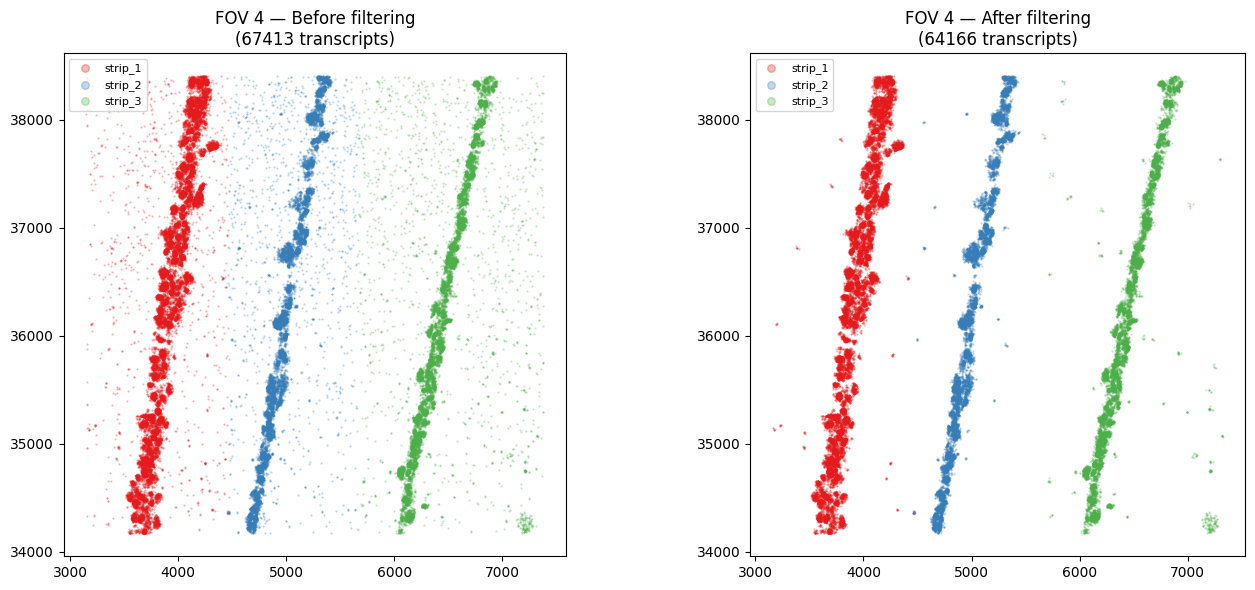

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fov_id = 4

fov_data = result[result['fov'] == fov_id]
strip_colours = {'strip_1': '#e41a1c', 'strip_2': '#377eb8', 'strip_3': '#4daf4a'}

# Before (all points)
ax = axes[0]
for strip, colour in strip_colours.items():
    sub = fov_data[fov_data['strip'] == strip]
    ax.scatter(sub['x_global_px_transformed'], sub['y_global_px_transformed'],
               s=0.3, alpha=0.3, c=colour, label=strip)
ax.set_title(f'FOV {fov_id} - Before filtering\n({len(fov_data)} transcripts)')
ax.set_aspect('equal')
ax.legend(markerscale=10, fontsize=8)

# After (noise removed)
ax = axes[1]
clean = fov_data[~fov_data['is_noise']]
for strip, colour in strip_colours.items():
    sub = clean[clean['strip'] == strip]
    ax.scatter(sub['x_global_px_transformed'], sub['y_global_px_transformed'],
               s=0.3, alpha=0.3, c=colour, label=strip)
ax.set_title(f'FOV {fov_id} - After filtering\n({len(clean)} transcripts)')
ax.set_aspect('equal')
ax.legend(markerscale=10, fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
summary = (
    result
    .groupby(['fov', 'strip'])
    .agg(
        n_total=('is_noise', 'size'),
        n_noise=('is_noise', 'sum'),
        eps_raw=('eps_raw', 'first'),
        eps_used=('eps_used', 'first'),
    )
    .assign(
        pct_noise=lambda x: (100 * x['n_noise'] / x['n_total']).round(1),
        n_kept=lambda x: x['n_total'] - x['n_noise'],
    )
)

print(summary.to_string())
print(f"\n{'='*50}")
print(f"Total: {summary['n_total'].sum()} → {summary['n_kept'].sum()} kept, "
      f"{summary['n_noise'].sum()} noise ({100 * summary['n_noise'].sum() / summary['n_total'].sum():.1f}%)")

             n_total  n_noise    eps_raw   eps_used  pct_noise  n_kept
fov strip                                                             
4   strip_1    30382      813   9.219544  20.000000        2.7   29569
    strip_2    18333     1098  22.478414  22.478414        6.0   17235
    strip_3    18698     1336  29.624801  29.624801        7.1   17362
5   strip_1    28519      742   9.219544  20.000000        2.6   27777
    strip_2    17265      894  17.733525  20.000000        5.2   16371
    strip_3    18086     1562  32.262978  30.000000        8.6   16524
8   strip_1    29523     1810  22.583600  22.583600        6.1   27713
    strip_2    19707     1269  22.191425  22.191425        6.4   18438
    strip_3    19068     2460  34.408865  30.000000       12.9   16608
9   strip_1    32115     1438  17.029386  20.000000        4.5   30677
    strip_2    17864     1196  24.515301  24.515301        6.7   16668
    strip_3    19772     1935  32.140317  30.000000        9.8   17837
10  st